# ***Model 3: Deeper CNN (Conv-Conv-Pool ×2) with dropout (0.3–0.5) using CIFAR-10 DataSet***

Adding Dropout before the final classification layer to the Deeper CNN Model. By applying dropout randomly, we are aiming to turns off some neurons during training and hoping This can reduce overfitting.

In [ ]:
# !cd /content/cifar10-cnn-classification-project && sed -i 's/from training\./from src.training./g' notebooks/*.ipynb


In [45]:
%cd /content

import os

if not os.path.exists("/content/cifar10-cnn-classification-project"):
    !git clone https://github.com/karimamzghi/cifar10-cnn-classification-project.git

%cd /content/cifar10-cnn-classification-project

from google.colab import drive
drive.mount("/content/drive")

/content
/content/cifar10-cnn-classification-project
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [46]:
MODEL_ID = 3
MODEL_NAME = "dropout_cnn"

In [47]:
# Import numpy lib
import importlib

import numpy as np

# Imports matptotlib lib
import matplotlib.pyplot as plt

# Imports tensorflow.Keras lib
import keras as keras
from keras import layers
from keras.backend import clear_session
from keras.optimizers import SGD

# Imports seaborn lib
import seaborn as sns

# Imports sklearn lib
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import confusion_matrix

import importlib

from src import config

import src.training.trainer as trainer
import src.training.evaluator as evaluator
import src.data_loader as data_loader

importlib.reload(trainer)
importlib.reload(evaluator)
importlib.reload(data_loader)
importlib.reload(config)

# Imports custom files aka config, experiment files, etc
from src.training.trainer import compile_model, train_model, save_model
from src.training.evaluator import (
    evaluate_model,
    get_predictions,
    calculate_precision_recall,
    save_confusion_matrix
)
from src.data_loader import load_data
from src.experiment_tracker import save_experiment_results    



In [48]:
# Load the data fromm cache using the load_data function from data_loader.py
from src.data_loader import load_data

x_train, y_train, x_val, y_val, x_test, y_test = load_data()

Loading cached data from Google Drive: /content/drive/MyDrive/cifar10_cache


In [49]:
# Clear any previous TensorFlow models from memory as TensorFlow can accumulate unnecessary objects in memory,
# especially if we are creating many models while tuning hyperparameters.
clear_session()

In [50]:
#  Build Model 3: Deeper CNN with Dropout.

deeper_dropout_model = build_dropout_cnn()

deeper_dropout_model.summary()

Model: "dropout_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 10, 10, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 168,682 (658.91 KB)

 Trainable params: 168,682 (658.91 KB)

 Non-trainable params: 0 (0.00 B)

In [51]:
# Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric
optimizer = keras.optimizers.SGD(
    learning_rate=config.LEARNING_RATE
)

deeper_dropout_model = compile_model(
    model=deeper_dropout_model,
    optimizer=optimizer,
    loss=config.CATEGORICAL_CROSSENTROPY,
    metrics=[config.ACCURACY]
)

In [52]:
# Train the model using the train_model function from trainer.py
history, train_time = train_model(
    model=deeper_dropout_model,
    x_train=x_train,
    y_train=y_train,
    x_val=x_val,
    y_val=y_val,
    batch_size=config.BATCH_SIZE,
    epochs=config.EPOCHS
)

Epoch 1/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.1074 - loss: 2.3029 - val_accuracy: 0.1548 - val_loss: 2.3006
Epoch 2/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.1241 - loss: 2.2997 - val_accuracy: 0.1856 - val_loss: 2.2975
Epoch 3/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.1401 - loss: 2.2963 - val_accuracy: 0.1851 - val_loss: 2.2938
Epoch 4/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.1485 - loss: 2.2920 - val_accuracy: 0.1850 - val_loss: 2.2882
Epoch 5/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.1582 - loss: 2.2850 - val_accuracy: 0.1873 - val_loss: 2.2785
Epoch 6/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.1691 - loss: 2.2719 - val_accuracy: 0.1884 - val_loss: 2.2591
Epoch 7/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.1781 - loss: 2.2469 - val_accuracy: 0.1893 - val_loss: 2.2214
Epoch 8/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.1839 - loss: 2.2075 - val_accuracy: 

In [53]:
# Sanity check: confirm we're using the new 70/15/15 split (15% of 60,000 = 9,000) and not the original Keras default test set (10,000)
print("x_test shape:", x_test.shape)
print("Expected: ~9000 (15% of 60000)")

# Evaluate the baseline model on the held-out test set 
test_loss, test_accuracy = evaluate_model(
    model=deeper_dropout_model,
    x_test=x_test,
    y_test=y_test
)

test_labels, test_predictions, y_pred_probs = get_predictions(
    model=deeper_dropout_model,
    x_test=x_test,
    y_test=y_test
)

precision, recall = calculate_precision_recall(
    test_labels=test_labels,
    test_predictions=test_predictions
)

print("Test accuracy:", test_accuracy)
print("Precision:", precision)
print("Recall:", recall)

x_test shape: (9000, 32, 32, 3)
Expected: ~9000 (15% of 60000)
x_test shape: (9000, 32, 32, 3)
Expected: ~9000 (15% of 60000)

Test loss: 1.9632447957992554
Test accuracy: 0.2935555577278137
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Precision: 0.3013  Recall: 0.2936
Test accuracy: 0.2935555577278137
Precision: 0.3013183801235505
Recall: 0.29355555555555557


In [54]:
# Save the model to a file under the models directory with a name that includes the model ID and model name
model_path = save_model(
    model=deeper_dropout_model,
    model_name=f"model_{MODEL_ID}_{MODEL_NAME}",
    models_dir=config.MODELS_DIR
)

Model saved to: ./models/model_3_dropout_cnn.keras


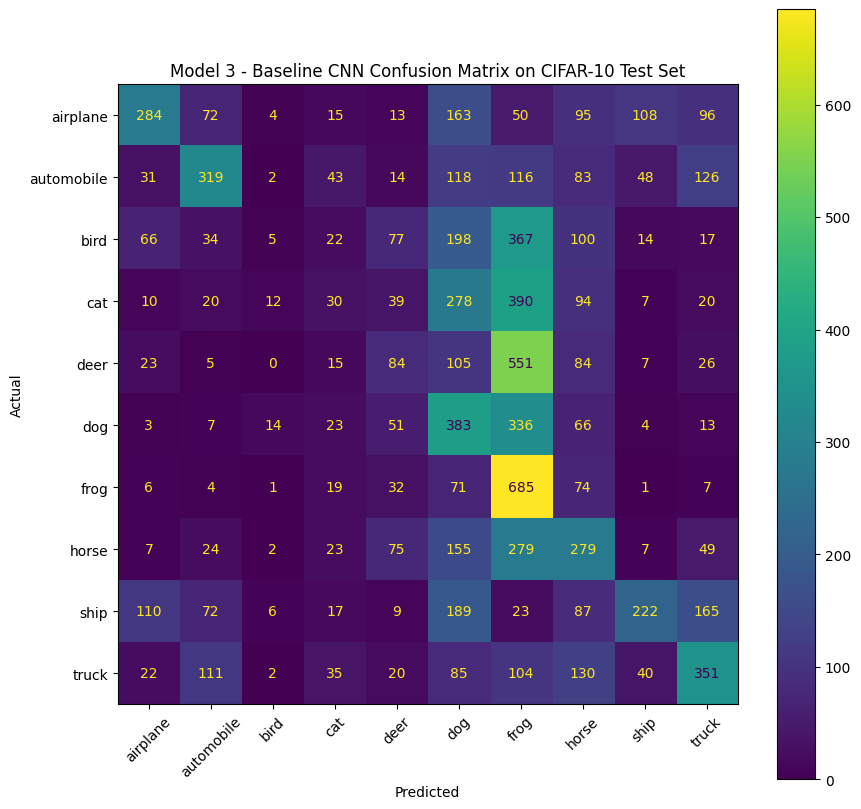

'./results/confusion_matrices/model_3_dropout_cnn_confusion_matrix.png'

In [55]:
# Save the confusion matrix to a file under the confusion_matrices directory with a name that includes the model ID and model name
confusion_matrix_path = (
    f"{config.CONFUSION_DIR}/model_{MODEL_ID}_{MODEL_NAME}_confusion_matrix.png"
)

save_confusion_matrix(
    test_labels=test_labels,
    test_predictions=test_predictions,
    output_path=confusion_matrix_path,
    title=f"Model {MODEL_ID} - Baseline CNN Confusion Matrix on CIFAR-10 Test Set"
)

In [56]:
experiment = {
    "model_id": MODEL_ID,
    "model_name": MODEL_NAME,
    "architecture": "Conv-Conv-Pool x2 + Dense(64) + Dropout(0.5)",
    "optimizer": "SGD",
    "learning_rate": config.LEARNING_RATE,
    "batch_size": config.BATCH_SIZE,
    "epochs": len(history.history["accuracy"]),
    "train_accuracy": history.history["accuracy"][-1],
    "validation_accuracy": history.history["val_accuracy"][-1],
    "test_accuracy": test_accuracy,
    "precision": precision,
    "recall": recall,
    "train_loss": history.history["loss"][-1],
    "validation_loss": history.history["val_loss"][-1],
    "test_loss": test_loss,
    "train_time_seconds": train_time,
    "model_path": model_path,
    "confusion_matrix_path": confusion_matrix_path,
    "notes": "Model 3 tests whether Dropout reduces overfitting compared with Model 2"
}

results_df = save_experiment_results(
    experiment,
    config.RESULTS_PATH
)

results_df

,model_id,model_name,architecture,augmentation,transfer_learning,optimizer,learning_rate,batch_size,epochs,train_accuracy,...,test_accuracy,train_loss,validation_loss,test_loss,model_path,confusion_matrix_path,notes,precision,recall,train_time_seconds
0,1,baseline_cnn,Conv2D(32) + MaxPool + Conv2D(64) + MaxPool + ...,No,No,SGD,0.001,64,20,0.379071,...,0.371000,1.782614,1.779500,1.782990,models/baseline_cnn.keras,results/confusion_matrices/model_1_baseline_cn...,Baseline CNN trained from scratch using SGD op...,NaN,NaN,NaN
1,2,deeper_cnn,Conv2D(32) + Conv2D(32) + MaxPool + Conv2D(64)...,NaN,NaN,SGD,0.001,64,20,0.397976,...,0.323333,1.692275,1.718160,2.002619,./models/model_2_deeper_cnn.keras,./results/confusion_matrices/model_2_deeper_cn...,Model 2 tests whether deeper Conv-Conv-Pool bl...,0.419784,0.323333,80.3
2,3,dropout_cnn,Conv-Conv-Pool x2 + Dense(64) + Dropout(0.5),NaN,NaN,SGD,0.001,64,20,0.274357,...,0.293556,1.979604,1.973125,1.963245,./models/model_3_dropout_cnn.keras,./results/confusion_matrices/model_3_dropout_c...,Model 3 tests whether Dropout reduces overfitt...,0.301318,0.293556,80.8


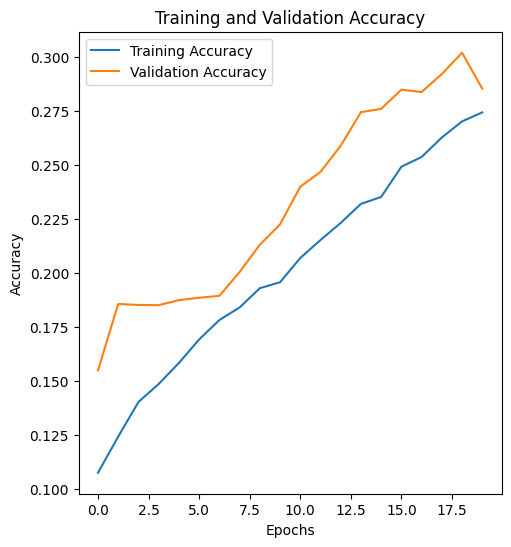

Accuracy curves saved to: ./results/plots/Model_3_dropout_cnn_accuracy_curves.png


In [57]:
# draw a plot of the training and validation accuracy over epochs
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Save the plot of the training and validation accuracy over epochs
os.makedirs(config.PLOTS_DIR, exist_ok=True)
accuracy_curves_path = (f"{config.PLOTS_DIR}/Model_{MODEL_ID}_{MODEL_NAME}_accuracy_curves.png")
plt.savefig(accuracy_curves_path, bbox_inches="tight")
plt.show()

print("Accuracy curves saved to:", accuracy_curves_path)

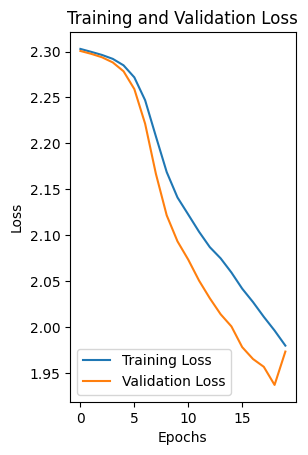

Loss curves saved to: ./results/plots/Model_3_dropout_cnn_loss_curves.png


In [58]:
# Draw the training and validation loss over epochs
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')    
plt.ylabel('Loss')
plt.legend()

# Save the plot of the training and validation loss over epochs
os.makedirs(config.PLOTS_DIR, exist_ok=True)
loss_curves_path = (f"{config.PLOTS_DIR}/Model_{MODEL_ID}_{MODEL_NAME}_loss_curves.png")
plt.savefig(loss_curves_path, bbox_inches="tight")
plt.show()

print("Loss curves saved to:", loss_curves_path)

In [59]:
# Deploy the model using Gradio interface
%cd /content/cifar10-cnn-classification-project
!PYTHONPATH=/content/cifar10-cnn-classification-project python deployment/app.py

/content/cifar10-cnn-classification-project
Traceback (most recent call last):
  File "/content/cifar10-cnn-classification-project/deployment/app.py", line 12, in <module>
    model = load_trained_model(MODEL_PATH)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/cifar10-cnn-classification-project/src/training/predictor.py", line 9, in load_trained_model
    model = load_model(model_path)
            ^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_api.py", line 203, in load_model
    raise ValueError(
ValueError: File not found: filepath=/content/cifar10-cnn-classification-project/models/model_1_baseline_cnn.keras. Please ensure the file is an accessible `.keras` zip file.
